In [ ]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    label_binarize
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc,
    f1_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sentence_transformers import SentenceTransformer

# =====================
# STEP 2: LOAD DATASET 
# =====================
train_path = "GUIDE_Train.csv"

df = pd.read_csv(
    train_path,
    nrows=10000,
    low_memory=False
)

print("="*60)
print("Dataset Shape:", df.shape)
print("="*60)

# =======================
# STEP 3: SELECT FEATURES
# =======================
selected_columns = [

    'Category',
    'MitreTechniques',
    'EntityType',
    'EvidenceRole',
    'SuspicionLevel',
    'LastVerdict',
    'ThreatFamily',
    'OSFamily',
    'CountryCode',
    'AlertTitle',      # REAL TEXT COLUMN
    'IncidentGrade'
]

df = df[selected_columns]

# =============================
# STEP 4: HANDLE MISSING VALUES
# =============================
df.fillna("Unknown", inplace=True)

# Save original
df_original = df.copy()

print("\nMissing Values Removed")

# ====================
# STEP 5: RULE-BASED BASELINE 
# ====================
def rule_based_classifier(text):

    text = str(text).lower()

    phishing_keywords = [
        'phishing',
        'credential',
        'login',
        'fake',
        'email',
        'spoof'
    ]

    malware_keywords = [
        'virus',
        'trojan',
        'malware',
        'worm',
        'ransomware'
    ]

    if any(
        word in text
        for word in phishing_keywords
    ):
        return "Phishing"

    elif any(
        word in text
        for word in malware_keywords
    ):
        return "Malware"

    return "Other"

df['RuleBasedPrediction'] = df[
    'AlertTitle'
].apply(rule_based_classifier)

print("Rule-Based Baseline Added")

# ===============================
# STEP 6: CREATE BETTER NLP TEXT
# ===============================
df['TicketText'] = (

    "Alert " +
    df['AlertTitle'].astype(str) +

    " Category " +
    df['Category'].astype(str) +

    " Mitre " +
    df['MitreTechniques'].astype(str) +

    " Entity " +
    df['EntityType'].astype(str) +

    " Threat " +
    df['ThreatFamily'].astype(str) +

    " Verdict " +
    df['LastVerdict'].astype(str)
)

print("Enhanced Ticket Text Created")

# =======================
# STEP 7: LABEL ENCODING
# 
# =======================
encoders = {}

categorical_cols = [

    'Category',
    'MitreTechniques',
    'EntityType',
    'EvidenceRole',
    'SuspicionLevel',
    'LastVerdict',
    'ThreatFamily',
    'OSFamily',
    'CountryCode',
    'IncidentGrade',
    'RuleBasedPrediction'
]

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

print("Encoding Complete")

# ================
# STEP 8: TF-IDF FEATURES
# ================
tfidf = TfidfVectorizer(
    max_features=300,
    stop_words='english',
    ngram_range=(1,2)
)

tfidf_features = tfidf.fit_transform(
    df['TicketText']
).toarray()

tfidf_df = pd.DataFrame(
    tfidf_features
)

tfidf_df.columns = [
    f"TFIDF_{i}"
    for i in range(
        tfidf_df.shape[1]
    )
]

print("TF-IDF Features Created")

# ====================================
# STEP 9: DISTILBERT EMBEDDINGS (LLM)
# ====================================

print("\nLoading DistilBERT...")

bert_model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

sample_text = df[
    'TicketText'
].tolist()

bert_embeddings = bert_model.encode(

    sample_text,

    batch_size=64,

    show_progress_bar=True,

    convert_to_numpy=True
)

bert_df = pd.DataFrame(
    bert_embeddings
)

bert_df.columns = [
    f"BERT_{i}"
    for i in range(
        bert_df.shape[1]
    )
]

print("DistilBERT Embeddings Created")

# ===========================
# STEP 10: COMBINE FEATURES
# ============================
X_numeric = df[[
    'Category',
    'MitreTechniques',
    'EntityType',
    'EvidenceRole',
    'SuspicionLevel',
    'LastVerdict',
    'ThreatFamily',
    'OSFamily',
    'CountryCode',
    'RuleBasedPrediction'
]]

X = pd.concat(

    [
        X_numeric.reset_index(drop=True),
        tfidf_df.reset_index(drop=True),
        bert_df.reset_index(drop=True)
    ],

    axis=1
)

X.columns = X.columns.astype(str)

y = df[
    'IncidentGrade'
]

print("\nFinal Feature Shape:")
print(X.shape)

# ==========================
# STEP 11: TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ======================
# STEP 12: BETTER SMOTE
# =====================

print("\nApplying SMOTE...")

class_counts = y_train.value_counts()

min_class_size = class_counts.min()

safe_neighbors = max(
    1,
    min(
        5,
        min_class_size - 1
    )
)

smote = SMOTE(

    random_state=42,

    k_neighbors=safe_neighbors
)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,
    y_train
)

print(
    "After SMOTE:",
    X_train_smote.shape
)

print(
    pd.Series(
        y_train_smote
    ).value_counts()
)

Dataset Shape: (10000, 45)

Missing Values Removed
Rule-Based Baseline Added
Enhanced Ticket Text Created
Encoding Complete
TF-IDF Features Created

Loading DistilBERT...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

DistilBERT Embeddings Created

Final Feature Shape:
(10000, 694)

Train Shape: (8000, 694)
Test Shape: (2000, 694)

Applying SMOTE...
After SMOTE: (14052, 694)
IncidentGrade
1    3513
0    3513
2    3513
3    3513
Name: count, dtype: int64



MODEL: Random Forest

Accuracy: 66.65 %

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       878
           1       0.48      0.39      0.43       422
           2       0.74      0.69      0.72       689
           3       0.29      0.36      0.32        11

    accuracy                           0.67      2000
   macro avg       0.55      0.56      0.55      2000
weighted avg       0.66      0.67      0.66      2000


Weighted F1 Score: 0.6604

Cross Validation Accuracy: 76.64 %

MODEL: Gradient Boosting

Accuracy: 62.85 %

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       878
           1       0.42      0.42      0.42       422
           2       0.72      0.65      0.68       689
           3       0.23      0.64      0.34        11

    accuracy                           0.63      2000
   macro avg       0.51      0.60      0.5

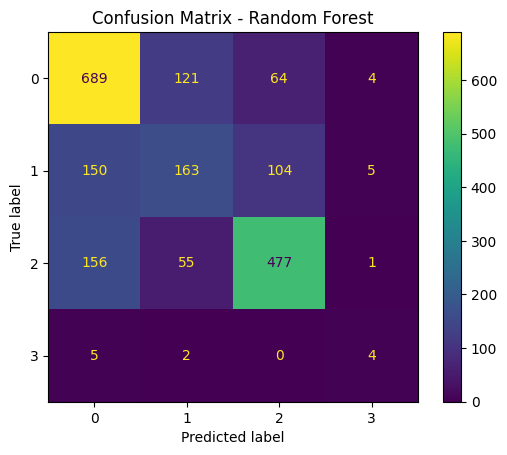

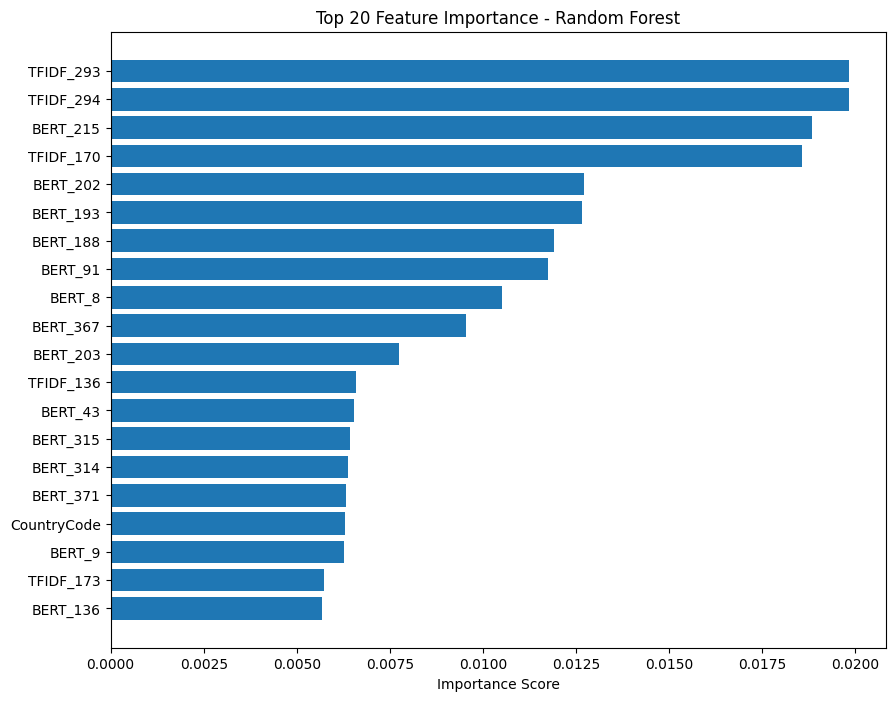

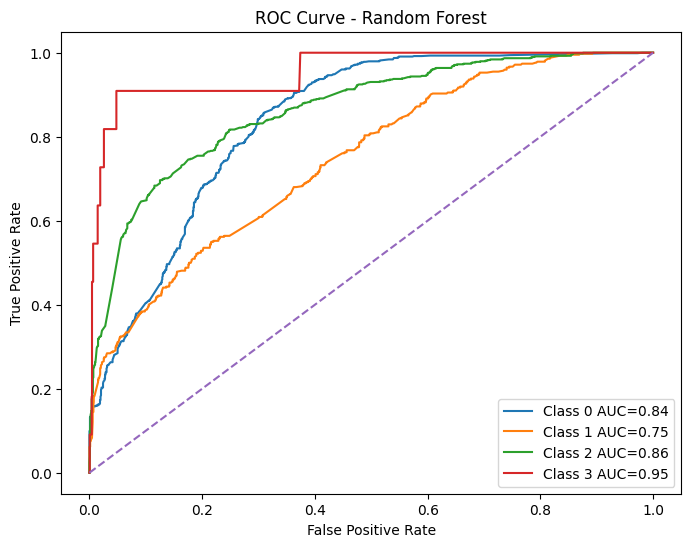

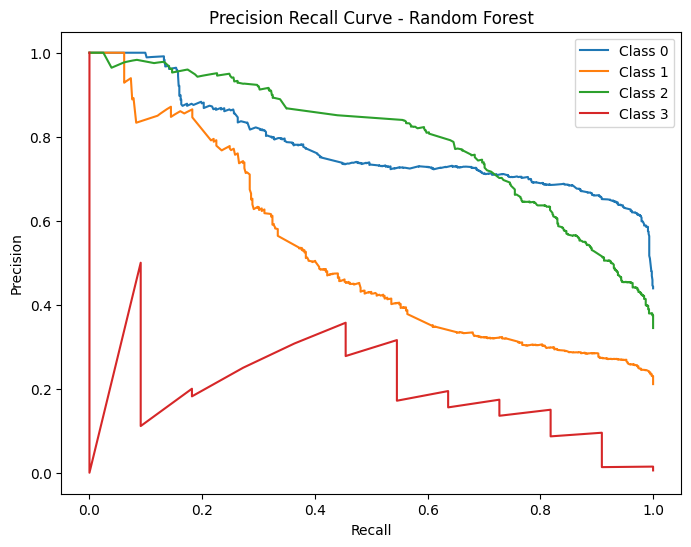

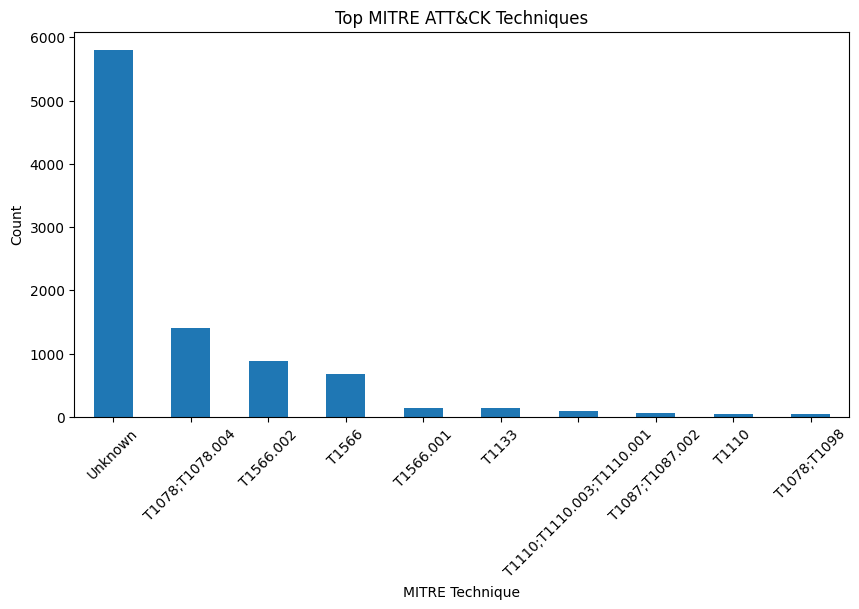

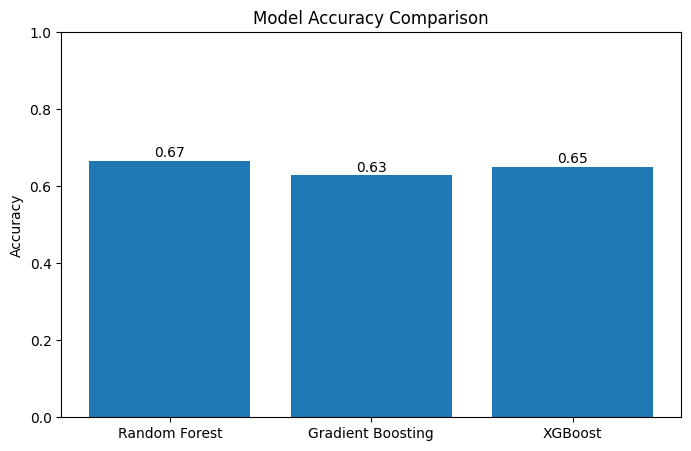


FINAL MODEL ACCURACIES
Random Forest : 66.65 %
Gradient Boosting : 62.85 %
XGBoost : 65.0 %


In [ ]:
# ================
# STEP 13: DEFINE MODELS 
# ================
models = {

    "Random Forest":
    RandomForestClassifier(

        n_estimators=150,
        max_depth=15,
        min_samples_split=5,

        class_weight='balanced',

        n_jobs=-1,

        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(

        n_estimators=100,

        learning_rate=0.08,

        random_state=42
    ),

    "XGBoost":
    XGBClassifier(

        n_estimators=150,

        learning_rate=0.05,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        eval_metric='mlogloss',

        tree_method='hist',

        n_jobs=-1,

        random_state=42
    )
}

# =================================
# STEP 14: TRAIN & EVALUATE MODELS
# =================================

results = {}

for name, model in models.items():

    print("\n" + "="*60)
    print("MODEL:", name)
    print("="*60)

    # Train model
    model.fit(

        X_train_smote,
        y_train_smote
    )

    # Prediction
    y_pred = model.predict(
        X_test
    )

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results[name] = accuracy

    print(
        "\nAccuracy:",
        round(
            accuracy * 100,
            2
        ),
        "%"
    )

    # Classification report
    print(
        "\nClassification Report:"
    )

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # Weighted F1 Score
    f1 = f1_score(

        y_test,
        y_pred,

        average='weighted'
    )

    print(
        "\nWeighted F1 Score:",
        round(f1, 4)
    )

    # Faster Cross Validation
    cv_scores = cross_val_score(

        model,

        X_train_smote,
        y_train_smote,

        cv=3,

        scoring='accuracy',

        n_jobs=-1
    )

    print(
        "\nCross Validation Accuracy:",
        round(
            cv_scores.mean() * 100,
            2
        ),
        "%"
    )

# ====================
# STEP 15: BEST MODEL 
# ====================

best_model_name = max(

    results,

    key=results.get
)

best_model = models[
    best_model_name
]

print(
    "\nBest Model:",
    best_model_name
)

# Final prediction
y_pred = best_model.predict(
    X_test
)

# ==========================
# GRAPH 1: CONFUSION MATRIX
# ==========================

cm = confusion_matrix(

    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

# ============================
# GRAPH 2: FEATURE IMPORTANCE
 
# =============================
if hasattr(
    best_model,
    'feature_importances_'
):

    importance = pd.DataFrame({

        'Feature':
        X.columns.astype(str),

        'Importance':
        best_model.feature_importances_

    })

    importance = importance.sort_values(

        by='Importance',

        ascending=False
    )

    plt.figure(
        figsize=(10,8)
    )

    plt.barh(

        importance[
            'Feature'
        ].head(20),

        importance[
            'Importance'
        ].head(20)
    )

    plt.title(
        f"Top 20 Feature Importance - {best_model_name}"
    )

    plt.xlabel(
        "Importance Score"
    )

    plt.gca().invert_yaxis()

    plt.show()

# ====================
# GRAPH 3: ROC CURVE
# =====================

y_test_bin = label_binarize(

    y_test,

    classes=np.unique(y)
)

y_score = best_model.predict_proba(
    X_test
)

plt.figure(
    figsize=(8,6)
)

for i in range(
    y_test_bin.shape[1]
):

    fpr, tpr, _ = roc_curve(

        y_test_bin[:, i],

        y_score[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(

        fpr,

        tpr,

        label=f'Class {i} AUC={roc_auc:.2f}'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend()

plt.show()

# ================================
# GRAPH 4: PRECISION-RECALL CURVE
# ================================

plt.figure(
    figsize=(8,6)
)

for i in range(
    y_test_bin.shape[1]
):

    precision, recall, _ = precision_recall_curve(

        y_test_bin[:, i],

        y_score[:, i]
    )

    plt.plot(

        recall,

        precision,

        label=f'Class {i}'
    )

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    f"Precision Recall Curve - {best_model_name}"
)

plt.legend()

plt.show()

# ====================================
# GRAPH 5: TOP MITRE ATT&CK TECHNIQUES
# ====================================

plt.figure(figsize=(10,5))

df_original[
    'MitreTechniques'
].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    "Top MITRE ATT&CK Techniques"
)

plt.xlabel(
    "MITRE Technique"
)

plt.ylabel(
    "Count"
)

plt.xticks(
    rotation=45
)

plt.show()

# ===================================
# GRAPH 6: MODEL ACCURACY COMPARISON 
# ===================================

plt.figure(figsize=(8,5))

bars = plt.bar(

    results.keys(),

    results.values()
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(0,1)

# Show accuracy value on bars
for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() +
        bar.get_width()/2,

        height + 0.01,

        f"{height:.2f}",

        ha='center'
    )

plt.show()


# ==============
# FINAL RESULTS
# ==============

print("\n" + "="*60)
print("FINAL MODEL ACCURACIES")
print("="*60)

for model, acc in results.items():

    print(

        model,

        ":",

        round(
            acc * 100,
            2
        ),

        "%"
    )